In [ ]:

# =========================
# 1. Imports and global config
# =========================

import os
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'COVID-19_Radiography_Dataset.zip', 'archive.zip', '智慧博物馆 - 物联网全案汇报.gslides', '智慧博物馆 - 物联网技术赋能全案.gslides']


In [ ]:
!unzip -q "/content/drive/MyDrive/archive.zip" -d /content/data

In [ ]:
import os

print(os.listdir('/content/data'))

['COVID-19_Radiography_Dataset']


In [ ]:
DATA_ROOT = "/content/data/COVID-19_Radiography_Dataset"

In [ ]:
# =========================
# 2. Paths and experiment settings
# =========================



# Optional: if your archive is still zipped in Google Drive, uncomment this.
# ARCHIVE_ZIP = "/content/drive/MyDrive/archive.zip"
# if not os.path.exists(DATA_ROOT):
#     !unzip -q "$ARCHIVE_ZIP" -d /content/data

CLASS_NAMES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

BASELINE_CKPT = "best_resnet18_cxr.pth"
MC_DROPOUT_CKPT = "best_resnet18_mc_dropout_cxr.pth"

OUTPUT_DIR = Path("uq_resnet_occlusion_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Training settings
BASELINE_EPOCHS = 10
BASELINE_LR = 1e-4

MC_DROPOUT_EPOCHS = 5
MC_DROPOUT_LR = 1e-5
MC_DROPOUT_P = 0.30

# MC Dropout settings
N_MC_EVAL = 30       # for evaluating full test set
N_MC_OCCLUSION = 20  # for occlusion; reduce to 10 for faster testing

In [ ]:
# =========================
# Reproducibility setting
# =========================

import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("SEED =", SEED)

SEED = 42


In [ ]:

# =========================
# 3. Load file paths and split dataset
# =========================

def collect_image_paths(data_root, class_names):
    rows = []
    data_root = Path(data_root)

    for cls in class_names:
        img_dir = data_root / cls / "images"
        if not img_dir.exists():
            raise FileNotFoundError(f"Cannot find image folder: {img_dir}")

        for fname in os.listdir(img_dir):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                rows.append({
                    "filepath": str(img_dir / fname),
                    "label_name": cls,
                    "label": CLASS_TO_IDX[cls]
                })

    return pd.DataFrame(rows)


df = collect_image_paths(DATA_ROOT, CLASS_NAMES)
print(df.head())
print("Total images:", len(df))
print(df["label_name"].value_counts().reindex(CLASS_NAMES))

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

                                            filepath label_name  label
0  /content/data/COVID-19_Radiography_Dataset/COV...      COVID      0
1  /content/data/COVID-19_Radiography_Dataset/COV...      COVID      0
2  /content/data/COVID-19_Radiography_Dataset/COV...      COVID      0
3  /content/data/COVID-19_Radiography_Dataset/COV...      COVID      0
4  /content/data/COVID-19_Radiography_Dataset/COV...      COVID      0
Total images: 21165
label_name
COVID               3616
Lung_Opacity        6012
Normal             10192
Viral Pneumonia     1345
Name: count, dtype: int64
Train size: 14815
Val size: 3175
Test size: 3175


In [ ]:

# =========================
# 4. Dataset, transforms, dataloaders
# =========================

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

class CXRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("L")
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        return img, label


train_dataset = CXRDataset(train_df, transform=train_transform)
val_dataset = CXRDataset(val_df, transform=eval_transform)
test_dataset = CXRDataset(test_df, transform=eval_transform)

class_sample_count = train_df["label"].value_counts().sort_index().values
class_weights = 1.0 / class_sample_count
sample_weights = train_df["label"].map(lambda x: class_weights[x]).values

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

print("Class counts:", class_sample_count)
print("Class weights:", class_weights)

Class counts: [2531 4208 7134  942]
Class weights: [0.0003951  0.00023764 0.00014017 0.00106157]


In [ ]:

# =========================
# 5. Model builders
# =========================

def build_resnet18(num_classes=NUM_CLASSES, pretrained=True):
    """Build ResNet-18 for single-channel CXR classification."""
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet18(weights=weights)

    # Change first conv layer from 3-channel RGB to 1-channel grayscale.
    old_conv = model.conv1
    model.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )

    # Initialise single-channel conv using the mean of RGB weights.
    if pretrained:
        with torch.no_grad():
            model.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    return model


def build_mc_dropout_from_baseline(baseline_model, dropout_p=0.30):
    """
    Copy the trained baseline model and insert Dropout before the final Linear layer.
    This preserves the baseline weights, then allows optional fine-tuning.
    """
    mc_model = copy.deepcopy(baseline_model)

    if isinstance(mc_model.fc, nn.Linear):
        old_fc = mc_model.fc
        mc_model.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            old_fc
        )
    elif isinstance(mc_model.fc, nn.Sequential):
        print("The model already has a Sequential classifier head.")
    else:
        raise TypeError(f"Unsupported fc layer type: {type(mc_model.fc)}")

    return mc_model

In [ ]:

# =========================
# 6. Training and evaluation helpers
# =========================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate_loss_acc(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def collect_logits_and_labels(model, loader, device):
    model.eval()
    all_logits = []
    all_labels = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        logits = model(images)
        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.detach().cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return all_logits.numpy(), all_labels.numpy()


def fit_model_with_checkpoint(
    model,
    train_loader,
    val_loader,
    checkpoint_path,
    epochs,
    lr,
    device,
    description="model"
):
    criterion = nn.CrossEntropyLoss()
    model = model.to(device)

    if os.path.exists(checkpoint_path):
        print(f"Loading existing {description} checkpoint: {checkpoint_path}")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        return model

    print(f"No checkpoint found. Training {description}...")
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    best_val_loss = float("inf")

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_loss_acc(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    print(f"Loading best {description} checkpoint.")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    return model

In [ ]:
# =========================
# Global config
# =========================

import os
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASELINE_EPOCHS = 5
BASELINE_LR = 1e-4

MC_DROPOUT_EPOCHS = 5
MC_DROPOUT_LR = 1e-4
MC_DROPOUT_P = 0.3
MC_DROPOUT_T = 30

TEMPERATURE_EPOCHS = 50

print("SEED:", SEED)
print("DEVICE:", DEVICE)

SEED: 42
DEVICE: cuda


In [ ]:

# =========================
# 7. Train/load Baseline ResNet
# =========================

baseline_model = build_resnet18(num_classes=NUM_CLASSES, pretrained=True)
baseline_model = fit_model_with_checkpoint(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    checkpoint_path=BASELINE_CKPT,
    epochs=BASELINE_EPOCHS,
    lr=BASELINE_LR,
    device=DEVICE,
    description="Baseline ResNet"
)

baseline_model.eval()
print(baseline_model.fc)

No checkpoint found. Training Baseline ResNet...


  0%|          | 0/463 [00:00<?, ?it/s]

Epoch [1/5] | Train Loss: 0.2684, Train Acc: 0.9005 | Val Loss: 0.1990, Val Acc: 0.9301


  0%|          | 0/463 [00:00<?, ?it/s]

Epoch [2/5] | Train Loss: 0.1601, Train Acc: 0.9415 | Val Loss: 0.2350, Val Acc: 0.9106


...

Epoch [3/5] | Train Loss: 0.1303, Train Acc: 0.9531 | Val Loss: 0.1390, Val Acc: 0.9506


  0%|          | 0/463 [00:00<?, ?it/s]

Epoch [4/5] | Train Loss: 0.1123, Train Acc: 0.9585 | Val Loss: 0.1775, Val Acc: 0.9405


  0%|          | 0/463 [00:00<?, ?it/s]

Epoch [5/5] | Train Loss: 0.1055, Train Acc: 0.9609 | Val Loss: 0.1607, Val Acc: 0.9480
Loading best Baseline ResNet checkpoint.
Linear(in_features=512, out_features=4, bias=True)


In [ ]:

# =========================
# 8. Train/load ResNet + MC Dropout
# =========================

mc_model = build_mc_dropout_from_baseline(baseline_model, dropout_p=MC_DROPOUT_P)
mc_model = fit_model_with_checkpoint(
    model=mc_model,
    train_loader=train_loader,
    val_loader=val_loader,
    checkpoint_path=MC_DROPOUT_CKPT,
    epochs=MC_DROPOUT_EPOCHS,
    lr=MC_DROPOUT_LR,
    device=DEVICE,
    description="ResNet + MC Dropout"
)

mc_model.eval()
print(mc_model.fc)

No checkpoint found. Training ResNet + MC Dropout...


  0%|          | 0/463 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db067e4ee80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7db067e4ee80>^
^^Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^^    
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
if w.is_alive():
     assert self._parent_pid == os.getpid(), 'can only test a child process' 
           ^ ^  ^^ ^ ^^^^^^^^^^^^^^
  Fil

Epoch [1/5] | Train Loss: 0.1186, Train Acc: 0.9570 | Val Loss: 0.1800, Val Acc: 0.9455


  0%|          | 0/463 [00:00<?, ?it/s]

...

Epoch [3/5] | Train Loss: 0.0982, Train Acc: 0.9646 | Val Loss: 0.1779, Val Acc: 0.9361


  0%|          | 0/463 [00:00<?, ?it/s]

Epoch [4/5] | Train Loss: 0.0956, Train Acc: 0.9652 | Val Loss: 0.1433, Val Acc: 0.9509


  0%|          | 0/463 [00:00<?, ?it/s]

Epoch [5/5] | Train Loss: 0.0820, Train Acc: 0.9707 | Val Loss: 0.1397, Val Acc: 0.9546
Loading best ResNet + MC Dropout checkpoint.
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=4, bias=True)
)


In [ ]:

# =========================
# 9. Probability and uncertainty helper functions
# =========================

METHOD_BASELINE = "baseline_resnet"
METHOD_MC = "resnet_mc_dropout"
METHOD_TS = "resnet_temperature_scaling"

METHOD_DISPLAY = {
    METHOD_BASELINE: "Baseline ResNet",
    METHOD_MC: "ResNet + MC Dropout",
    METHOD_TS: "ResNet + Temperature Scaling"
}


def softmax_np(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)


def entropy_np(probs, eps=1e-12):
    return -np.sum(probs * np.log(probs + eps), axis=1)


def margin_np(probs):
    sorted_probs = np.sort(probs, axis=1)
    return sorted_probs[:, -1] - sorted_probs[:, -2]


def one_hot(labels, num_classes=NUM_CLASSES):
    return np.eye(num_classes)[labels]


def brier_score_multiclass(y_true, probs):
    y_oh = one_hot(y_true, probs.shape[1])
    return float(np.mean(np.sum((probs - y_oh) ** 2, axis=1)))


def nll_score(y_true, probs, eps=1e-12):
    return float(-np.mean(np.log(probs[np.arange(len(y_true)), y_true] + eps)))


def expected_calibration_error(y_true, probs, n_bins=10):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correctness = (predictions == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []

    for i in range(n_bins):
        left = bin_edges[i]
        right = bin_edges[i + 1]

        if i == 0:
            mask = (confidences >= left) & (confidences <= right)
        else:
            mask = (confidences > left) & (confidences <= right)

        n_bin = int(mask.sum())
        prop = n_bin / len(y_true)

        if n_bin > 0:
            bin_acc = float(correctness[mask].mean())
            bin_conf = float(confidences[mask].mean())
            gap = abs(bin_acc - bin_conf)
            ece += prop * gap
        else:
            bin_acc = np.nan
            bin_conf = np.nan
            gap = np.nan

        rows.append({
            "bin": i + 1,
            "bin_left": left,
            "bin_right": right,
            "n": n_bin,
            "accuracy": bin_acc,
            "confidence": bin_conf,
            "gap": gap,
            "proportion": prop
        })

    return float(ece), pd.DataFrame(rows)


def assign_case_type(row):
    if row["correct"] and row["confidence"] >= HIGH_CONF_THRESHOLD:
        return "Correct + high confidence"
    elif (not row["correct"]) and row["confidence"] >= HIGH_CONF_THRESHOLD:
        return "Overconfident failure"
    elif row["correct"] and row["entropy"] >= UNCERTAIN_ENTROPY_THRESHOLD:
        return "Correct but uncertain"
    elif (not row["correct"]) and row["entropy"] >= UNCERTAIN_ENTROPY_THRESHOLD:
        return "Incorrect but uncertain"
    elif row["correct"]:
        return "Other correct"
    else:
        return "Other incorrect"


def build_prediction_df(base_df, y_true, probs, method):
    pred = np.argmax(probs, axis=1)
    conf = np.max(probs, axis=1)

    out = base_df.reset_index(drop=True).copy()
    out["method"] = method
    out["method_display"] = METHOD_DISPLAY[method]
    out["true_label"] = y_true
    out["pred_label"] = pred
    out["true_class"] = out["true_label"].map(lambda x: CLASS_NAMES[int(x)])
    out["pred_class"] = out["pred_label"].map(lambda x: CLASS_NAMES[int(x)])
    out["correct"] = out["true_label"] == out["pred_label"]
    out["confidence"] = conf
    out["entropy"] = entropy_np(probs)
    out["top1_top2_margin"] = margin_np(probs)
    out["case_type"] = out.apply(assign_case_type, axis=1)
    return out


def summarise_predictions(y_true, probs, method):
    pred = np.argmax(probs, axis=1)
    conf = np.max(probs, axis=1)
    ent = entropy_np(probs)
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    try:
        auc_macro = roc_auc_score(y_true_bin, probs, average="macro", multi_class="ovr")
    except Exception:
        auc_macro = np.nan

    ece, _ = expected_calibration_error(y_true, probs, n_bins=10)

    return {
        "method": method,
        "method_display": METHOD_DISPLAY[method],
        "accuracy": accuracy_score(y_true, pred),
        "precision_macro": precision_score(y_true, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, pred, average="macro", zero_division=0),
        "auc_macro_ovr": auc_macro,
        "mean_confidence": float(np.mean(conf)),
        "mean_entropy": float(np.mean(ent)),
        "brier_score": brier_score_multiclass(y_true, probs),
        "nll": nll_score(y_true, probs),
        "ece": ece
    }

In [ ]:

# =========================
# 10. Temperature Scaling
# =========================

class TemperatureScaler(nn.Module):
    """
    Post-hoc temperature scaling.
    It learns one scalar T on the validation set.
    Calibrated probabilities = softmax(logits / T).
    """
    def __init__(self, init_temperature=1.0):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(float(init_temperature))))

    @property
    def temperature(self):
        return torch.exp(self.log_temperature).clamp(min=1e-3, max=100.0)

    def forward(self, logits):
        return logits / self.temperature


def fit_temperature_scaler(val_logits_np, val_labels_np, max_iter=200, lr=0.01):
    val_logits = torch.tensor(val_logits_np, dtype=torch.float32, device=DEVICE)
    val_labels = torch.tensor(val_labels_np, dtype=torch.long, device=DEVICE)

    scaler = TemperatureScaler(init_temperature=1.0).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.LBFGS([scaler.log_temperature], lr=lr, max_iter=max_iter)

    def closure():
        optimizer.zero_grad()
        loss = criterion(scaler(val_logits), val_labels)
        loss.backward()
        return loss

    before_loss = criterion(val_logits, val_labels).item()
    optimizer.step(closure)
    after_loss = criterion(scaler(val_logits), val_labels).item()

    T = float(scaler.temperature.detach().cpu().item())
    print(f"Temperature T = {T:.4f}")
    print(f"Validation NLL before TS: {before_loss:.4f}")
    print(f"Validation NLL after  TS: {after_loss:.4f}")
    return T, scaler

In [ ]:
# =========================
# 11. MC Dropout prediction helpers
# =========================

def enable_dropout_only(model):
    """
    Keep the model in eval mode, but activate Dropout layers only.
    This avoids updating BatchNorm statistics during MC sampling.
    """
    model.eval()
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()


@torch.no_grad()
def predict_mc_dropout_loader(model, loader, n_mc=30, device=DEVICE):
    all_probs = []
    all_labels = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        mc_probs = []

        for _ in range(n_mc):
            enable_dropout_only(model)
            logits = model(images)
            probs = F.softmax(logits, dim=1)
            mc_probs.append(probs.detach().cpu())

        mean_probs = torch.stack(mc_probs, dim=0).mean(dim=0)
        all_probs.append(mean_probs)
        all_labels.append(labels.detach().cpu())

    all_probs = torch.cat(all_probs, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()
    model.eval()
    return all_probs, all_labels


@torch.no_grad()
def predict_tensor_baseline(input_tensor):
    baseline_model.eval()
    logits = baseline_model(input_tensor.to(DEVICE))
    probs = F.softmax(logits, dim=1)[0]
    return probs.detach().cpu().numpy()


@torch.no_grad()
def predict_tensor_temperature(input_tensor, temperature):
    baseline_model.eval()
    logits = baseline_model(input_tensor.to(DEVICE))
    probs = F.softmax(logits / temperature, dim=1)[0]
    return probs.detach().cpu().numpy()


@torch.no_grad()
def predict_tensor_mc_dropout(input_tensor, n_mc=N_MC_OCCLUSION):
    input_tensor = input_tensor.to(DEVICE)
    probs_list = []

    for _ in range(n_mc):
        enable_dropout_only(mc_model)
        logits = mc_model(input_tensor)
        probs = F.softmax(logits, dim=1)[0]
        probs_list.append(probs.detach().cpu())

    mc_model.eval()
    mean_probs = torch.stack(probs_list, dim=0).mean(dim=0).numpy()
    return mean_probs


def predict_tensor_by_method(input_tensor, method, temperature=None):
    if method == METHOD_BASELINE:
        return predict_tensor_baseline(input_tensor)
    elif method == METHOD_TS:
        if temperature is None:
            raise ValueError("temperature must be provided for Temperature Scaling.")
        return predict_tensor_temperature(input_tensor, temperature)
    elif method == METHOD_MC:
        return predict_tensor_mc_dropout(input_tensor, n_mc=N_MC_OCCLUSION)
    else:
        raise ValueError(f"Unknown method: {method}")


In [ ]:
# =========================
# 12. Evaluate three uncertainty methods on the test set
# =========================

# Baseline logits/probs
val_logits, val_labels = collect_logits_and_labels(baseline_model, val_loader, DEVICE)
test_logits, test_labels = collect_logits_and_labels(baseline_model, test_loader, DEVICE)

baseline_probs = softmax_np(test_logits)

# Temperature Scaling
best_temperature, temperature_scaler = fit_temperature_scaler(val_logits, val_labels)
ts_probs = softmax_np(test_logits / best_temperature)

# MC Dropout
mc_probs, mc_labels = predict_mc_dropout_loader(mc_model, test_loader, n_mc=N_MC_EVAL, device=DEVICE)
assert np.array_equal(test_labels, mc_labels), "Label order mismatch between baseline and MC Dropout."

# Summary metrics
metrics_summary = pd.DataFrame([
    summarise_predictions(test_labels, baseline_probs, METHOD_BASELINE),
    summarise_predictions(test_labels, mc_probs, METHOD_MC),
    summarise_predictions(test_labels, ts_probs, METHOD_TS)
])

metrics_summary.to_csv(OUTPUT_DIR / "method_metrics_summary.csv", index=False)
metrics_summary.round(4)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Temperature T = 1.0201
Validation NLL before TS: 0.1390
Validation NLL after  TS: 0.1390


  0%|          | 0/100 [00:00<?, ?it/s]

,method,method_display,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,mean_confidence,mean_entropy,brier_score,nll,ece
0,baseline_resnet,Baseline ResNet,0.9424,0.9505,0.9494,0.9495,0.9919,0.9506,0.1375,0.0853,0.1585,0.0098
1,resnet_mc_dropout,ResNet + MC Dropout,0.9458,0.9551,0.9559,0.9555,0.9927,0.9579,0.1117,0.0842,0.1551,0.0150
2,resnet_temperature_scaling,ResNet + Temperature Scaling,0.9424,0.9505,0.9494,0.9495,0.9919,0.9492,0.1417,0.0853,0.1581,0.0088


In [ ]:
# =========================
# Thresholds for case type
# =========================

import numpy as np

HIGH_CONF_THRESHOLD = 0.90

# 4-class classification:
# COVID / Lung_Opacity / Normal / Viral Pneumonia
# maximum entropy = log(4) ≈ 1.386
NUM_CLASSES = 4
MAX_ENTROPY = np.log(NUM_CLASSES)

# 可以先用最大熵的 50% 作为 uncertain threshold
UNCERTAIN_ENTROPY_THRESHOLD = 0.5 * MAX_ENTROPY

print("HIGH_CONF_THRESHOLD:", HIGH_CONF_THRESHOLD)
print("MAX_ENTROPY:", MAX_ENTROPY)
print("UNCERTAIN_ENTROPY_THRESHOLD:", UNCERTAIN_ENTROPY_THRESHOLD)

HIGH_CONF_THRESHOLD: 0.9
MAX_ENTROPY: 1.3862943611198906
UNCERTAIN_ENTROPY_THRESHOLD: 0.6931471805599453


In [ ]:
# =========================
# 13. Build prediction dataframes for all methods
# =========================

baseline_result_df = build_prediction_df(test_df, test_labels, baseline_probs, METHOD_BASELINE)
mc_result_df = build_prediction_df(test_df, test_labels, mc_probs, METHOD_MC)
ts_result_df = build_prediction_df(test_df, test_labels, ts_probs, METHOD_TS)

all_test_results_df = pd.concat(
    [baseline_result_df, mc_result_df, ts_result_df],
    ignore_index=True
)

all_test_results_df.to_csv(OUTPUT_DIR / "all_test_predictions_by_method.csv", index=False)

print("Case type counts by method:")
print(pd.crosstab(all_test_results_df["method_display"], all_test_results_df["case_type"]))

baseline_result_df.head()


Case type counts by method:
case_type                     Correct + high confidence  \
method_display                                            
Baseline ResNet                                    2667   
ResNet + MC Dropout                                2733   
ResNet + Temperature Scaling                       2660   

case_type                     Correct but uncertain  Incorrect but uncertain  \
method_display                                                                 
Baseline ResNet                                  42                       34   
ResNet + MC Dropout                              22                       17   
ResNet + Temperature Scaling                     45                       37   

case_type                     Other correct  Other incorrect  \
method_display                                                 
Baseline ResNet                         283               98   
ResNet + MC Dropout                     248               99   
ResNet + Temperatur

,filepath,label_name,label,method,method_display,true_label,pred_label,true_class,pred_class,correct,confidence,entropy,top1_top2_margin,case_type
0,/content/data/COVID-19_Radiography_Dataset/Nor...,Normal,2,baseline_resnet,Baseline ResNet,2,1,Normal,Lung_Opacity,False,0.634478,0.662206,0.269681,Other incorrect
1,/content/data/COVID-19_Radiography_Dataset/COV...,COVID,0,baseline_resnet,Baseline ResNet,0,0,COVID,COVID,True,0.989918,0.057547,0.980047,Correct + high confidence
2,/content/data/COVID-19_Radiography_Dataset/COV...,COVID,0,baseline_resnet,Baseline ResNet,0,0,COVID,COVID,True,0.999999,0.000010,0.999999,Correct + high confidence
3,/content/data/COVID-19_Radiography_Dataset/Vir...,Viral Pneumonia,3,baseline_resnet,Baseline ResNet,3,3,Viral Pneumonia,Viral Pneumonia,True,0.999509,0.004390,0.999059,Correct + high confidence
4,/content/data/COVID-19_Radiography_Dataset/COV...,COVID,0,baseline_resnet,Baseline ResNet,0,0,COVID,COVID,True,0.999998,0.000027,0.999997,Correct + high confidence


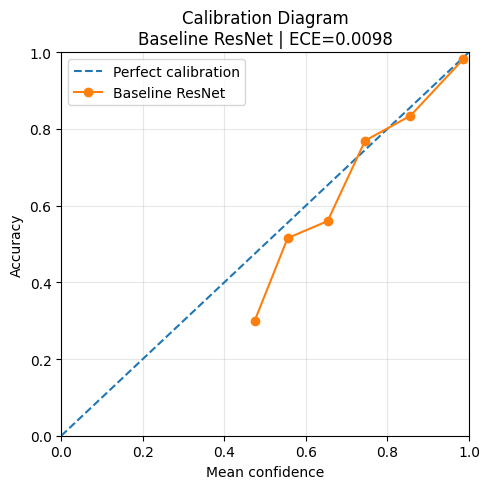

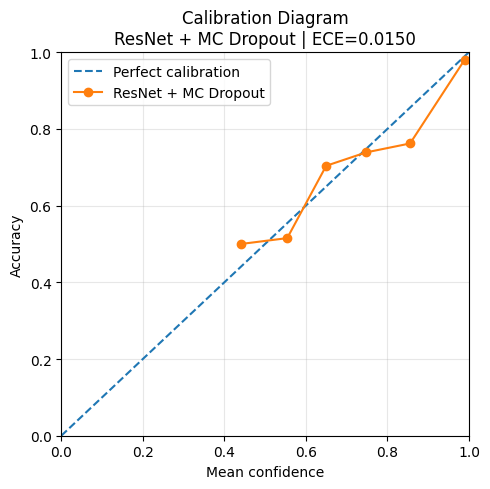

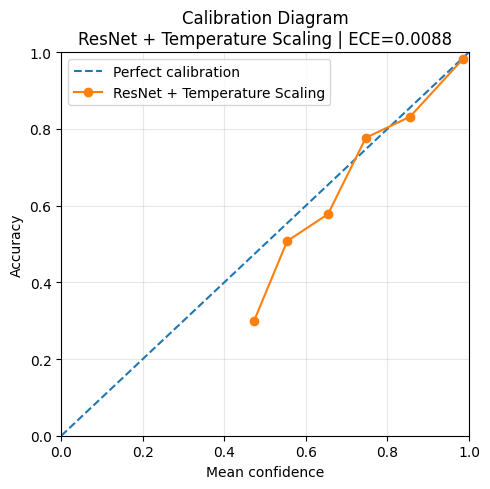

In [ ]:
# =========================
# 14. Calibration diagrams
# =========================

def plot_calibration_diagram(y_true, probs, method, n_bins=10, save=True):
    ece, bin_df = expected_calibration_error(y_true, probs, n_bins=n_bins)

    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.plot(
        bin_df["confidence"],
        bin_df["accuracy"],
        marker="o",
        label=f"{METHOD_DISPLAY[method]}"
    )
    plt.xlabel("Mean confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Calibration Diagram\n{METHOD_DISPLAY[method]} | ECE={ece:.4f}")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save:
        safe_name = method.replace(" ", "_").replace("+", "plus")
        plt.savefig(OUTPUT_DIR / f"calibration_diagram_{safe_name}.png", dpi=300, bbox_inches="tight")
        bin_df.to_csv(OUTPUT_DIR / f"calibration_bins_{safe_name}.csv", index=False)

    plt.show()
    return bin_df


calibration_bins = {}
calibration_bins[METHOD_BASELINE] = plot_calibration_diagram(test_labels, baseline_probs, METHOD_BASELINE)
calibration_bins[METHOD_MC] = plot_calibration_diagram(test_labels, mc_probs, METHOD_MC)
calibration_bins[METHOD_TS] = plot_calibration_diagram(test_labels, ts_probs, METHOD_TS)


In [ ]:
# =========================
# Occlusion sample setting
# =========================

# None = use all uncertain samples
# 5 / 10 / 20 = only use first few samples for quick testing

MAX_UNCERTAIN_SAMPLES = 5

print("MAX_UNCERTAIN_SAMPLES:", MAX_UNCERTAIN_SAMPLES)

MAX_UNCERTAIN_SAMPLES: 5


In [ ]:
# =========================
# 15. Select uncertain samples for regional occlusion
# =========================

# To compare the three methods fairly, we use the same image set for all methods.
# Here the sample set is defined by Baseline ResNet uncertainty, matching your previous 257 uncertain samples idea.

uncertain_sample_df = baseline_result_df[
    baseline_result_df["case_type"].isin([
        "Correct but uncertain",
        "Incorrect but uncertain"
    ])
].copy().reset_index(drop=True)

if MAX_UNCERTAIN_SAMPLES is not None:
    uncertain_sample_df = uncertain_sample_df.head(MAX_UNCERTAIN_SAMPLES).copy()

uncertain_sample_df["sample_id"] = np.arange(1, len(uncertain_sample_df) + 1)

uncertain_sample_df.to_csv(OUTPUT_DIR / "baseline_uncertain_samples_used_for_occlusion.csv", index=False)

print("Total uncertain samples selected:", len(uncertain_sample_df))
print(uncertain_sample_df["case_type"].value_counts())

uncertain_sample_df[[
    "sample_id", "filepath", "true_class", "pred_class", "correct", "confidence", "entropy", "case_type"
]].head()


Total uncertain samples selected: 5
case_type
Incorrect but uncertain    3
Correct but uncertain      2
Name: count, dtype: int64


,sample_id,filepath,true_class,pred_class,correct,confidence,entropy,case_type
0,1,/content/data/COVID-19_Radiography_Dataset/Lun...,Lung_Opacity,Normal,False,0.520579,0.705472,Incorrect but uncertain
1,2,/content/data/COVID-19_Radiography_Dataset/Nor...,Normal,Normal,True,0.622946,0.936676,Correct but uncertain
2,3,/content/data/COVID-19_Radiography_Dataset/Lun...,Lung_Opacity,Lung_Opacity,True,0.646864,0.711536,Correct but uncertain
3,4,/content/data/COVID-19_Radiography_Dataset/Lun...,Lung_Opacity,COVID,False,0.641655,0.931249,Incorrect but uncertain
4,5,/content/data/COVID-19_Radiography_Dataset/Lun...,Lung_Opacity,Normal,False,0.590568,0.777892,Incorrect but uncertain


In [ ]:
# =========================
# 16. 7×7 regional occlusion functions
# =========================

def load_image_tensor(filepath):
    img = Image.open(filepath).convert("L")
    input_tensor = eval_transform(img).unsqueeze(0).to(DEVICE)
    return img, input_tensor


def mask_grid_cell(image_tensor, row_idx, col_idx, grid_size=7, fill_value=0.0):
    """
    Mask one grid cell in the already-normalised image tensor.
    image_tensor shape: [1, 1, H, W]
    """
    masked = image_tensor.clone()
    _, _, H, W = masked.shape

    cell_h = H // grid_size
    cell_w = W // grid_size

    h1 = row_idx * cell_h
    h2 = (row_idx + 1) * cell_h if row_idx < grid_size - 1 else H

    w1 = col_idx * cell_w
    w2 = (col_idx + 1) * cell_w if col_idx < grid_size - 1 else W

    masked[:, :, h1:h2, w1:w2] = fill_value
    return masked


def summarise_prob_vector(prob):
    pred_label = int(np.argmax(prob))
    confidence = float(np.max(prob))
    entropy = float(-np.sum(prob * np.log(prob + 1e-12)))
    sorted_prob = np.sort(prob)
    margin = float(sorted_prob[-1] - sorted_prob[-2])

    return {
        "pred_label": pred_label,
        "pred_class": CLASS_NAMES[pred_label],
        "confidence": confidence,
        "entropy": entropy,
        "top1_top2_margin": margin
    }


def regional_occlusion_analysis(row, method, temperature=None, grid_size=7):
    filepath = row["filepath"]
    _, input_tensor = load_image_tensor(filepath)

    original_prob = predict_tensor_by_method(
        input_tensor,
        method=method,
        temperature=temperature
    )
    original = summarise_prob_vector(original_prob)

    records = []

    for r in range(grid_size):
        for c in range(grid_size):
            masked_tensor = mask_grid_cell(
                input_tensor,
                row_idx=r,
                col_idx=c,
                grid_size=grid_size,
                fill_value=MASK_FILL_VALUE
            )

            masked_prob = predict_tensor_by_method(
                masked_tensor,
                method=method,
                temperature=temperature
            )
            masked = summarise_prob_vector(masked_prob)

            records.append({
                "sample_id": int(row["sample_id"]),
                "method": method,
                "method_display": METHOD_DISPLAY[method],
                "filepath": filepath,
                "true_label": int(row["true_label"]),
                "true_class": row["true_class"],
                "baseline_case_type": row["case_type"],

                "original_pred_label": original["pred_label"],
                "original_pred_class": original["pred_class"],
                "masked_pred_label": masked["pred_label"],
                "masked_pred_class": masked["pred_class"],
                "prediction_changed": original["pred_label"] != masked["pred_label"],

                "original_confidence": original["confidence"],
                "masked_confidence": masked["confidence"],
                "confidence_change": masked["confidence"] - original["confidence"],

                "original_entropy": original["entropy"],
                "masked_entropy": masked["entropy"],
                "entropy_change": masked["entropy"] - original["entropy"],

                "original_margin": original["top1_top2_margin"],
                "masked_margin": masked["top1_top2_margin"],
                "margin_change": masked["top1_top2_margin"] - original["top1_top2_margin"],

                "grid_row": r,
                "grid_col": c
            })

    return pd.DataFrame(records)


In [ ]:
# =========================
# Occlusion grid setting
# =========================

GRID_SIZE = 7

print("GRID_SIZE:", GRID_SIZE)
print("Total regions per image:", GRID_SIZE * GRID_SIZE)

GRID_SIZE: 7
Total regions per image: 49


In [ ]:
# =========================
# Occlusion mask setting
# =========================

# When masking a grid region, fill that region with this value.
# If the image tensor has been normalized, 0.0 means roughly the mean/neutral value.
MASK_FILL_VALUE = 0.0

print("MASK_FILL_VALUE:", MASK_FILL_VALUE)

MASK_FILL_VALUE: 0.0


In [ ]:
# =========================
# 17. Run 7×7 occlusion for all three methods
# =========================

methods_to_run = [METHOD_BASELINE, METHOD_MC, METHOD_TS]

all_regional_results = []

for method in methods_to_run:
    print("\n" + "=" * 80)
    print("Running regional occlusion for:", METHOD_DISPLAY[method])
    print("=" * 80)

    method_records = []
    for _, row in tqdm(uncertain_sample_df.iterrows(), total=len(uncertain_sample_df)):
        one_df = regional_occlusion_analysis(
            row=row,
            method=method,
            temperature=best_temperature,
            grid_size=GRID_SIZE
        )
        method_records.append(one_df)

    method_regional_df = pd.concat(method_records, ignore_index=True)
    method_regional_df.to_csv(
        OUTPUT_DIR / f"regional_occlusion_{method}.csv",
        index=False
    )
    all_regional_results.append(method_regional_df)

regional_df = pd.concat(all_regional_results, ignore_index=True)
regional_df["abs_entropy_change"] = regional_df["entropy_change"].abs()
regional_df["abs_confidence_change"] = regional_df["confidence_change"].abs()

regional_df.to_csv(OUTPUT_DIR / "regional_occlusion_all_methods.csv", index=False)

print("Regional occlusion rows:", len(regional_df))
regional_df.head()



Running regional occlusion for: Baseline ResNet


  0%|          | 0/5 [00:00<?, ?it/s]


Running regional occlusion for: ResNet + MC Dropout


  0%|          | 0/5 [00:00<?, ?it/s]


Running regional occlusion for: ResNet + Temperature Scaling


  0%|          | 0/5 [00:00<?, ?it/s]

Regional occlusion rows: 735


,sample_id,method,method_display,filepath,true_label,true_class,baseline_case_type,original_pred_label,original_pred_class,masked_pred_label,...,original_entropy,masked_entropy,entropy_change,original_margin,masked_margin,margin_change,grid_row,grid_col,abs_entropy_change,abs_confidence_change
0,1,baseline_resnet,Baseline ResNet,/content/data/COVID-19_Radiography_Dataset/Lun...,1,Lung_Opacity,Incorrect but uncertain,2,Normal,2,...,0.705472,0.708164,0.002692,0.043103,0.010379,-0.032724,0,0,0.002692,0.016523
1,1,baseline_resnet,Baseline ResNet,/content/data/COVID-19_Radiography_Dataset/Lun...,1,Lung_Opacity,Incorrect but uncertain,2,Normal,1,...,0.705472,0.722248,0.016776,0.043103,0.026652,-0.016452,0,1,0.016776,0.009770
2,1,baseline_resnet,Baseline ResNet,/content/data/COVID-19_Radiography_Dataset/Lun...,1,Lung_Opacity,Incorrect but uncertain,2,Normal,2,...,0.705472,0.697634,-0.007837,0.043103,0.066867,0.023764,0,2,0.007837,0.012426
3,1,baseline_resnet,Baseline ResNet,/content/data/COVID-19_Radiography_Dataset/Lun...,1,Lung_Opacity,Incorrect but uncertain,2,Normal,1,...,0.705472,0.720193,0.014721,0.043103,0.087538,0.044435,0,3,0.014721,0.020480
4,1,baseline_resnet,Baseline ResNet,/content/data/COVID-19_Radiography_Dataset/Lun...,1,Lung_Opacity,Incorrect but uncertain,2,Normal,1,...,0.705472,0.735445,0.029973,0.043103,0.097172,0.054069,0,4,0.029973,0.023436


In [ ]:
# =========================
# 18. Summarise regional occlusion results
# =========================

regional_summary = regional_df.groupby(["method", "method_display", "baseline_case_type"]).agg(
    n_samples=("sample_id", "nunique"),
    n_regions=("sample_id", "count"),
    prediction_changed_rate=("prediction_changed", "mean"),
    mean_confidence_change=("confidence_change", "mean"),
    mean_abs_confidence_change=("abs_confidence_change", "mean"),
    mean_entropy_change=("entropy_change", "mean"),
    mean_abs_entropy_change=("abs_entropy_change", "mean")
).reset_index()

regional_summary.to_csv(OUTPUT_DIR / "regional_occlusion_summary_by_method_case.csv", index=False)
regional_summary.round(4)


,method,method_display,baseline_case_type,n_samples,n_regions,prediction_changed_rate,mean_confidence_change,mean_abs_confidence_change,mean_entropy_change,mean_abs_entropy_change
0,baseline_resnet,Baseline ResNet,Correct but uncertain,2,98,0.0918,-0.0119,0.0767,-0.0009,0.0964
1,baseline_resnet,Baseline ResNet,Incorrect but uncertain,3,147,0.2517,0.0080,0.0669,0.0009,0.0739
2,resnet_mc_dropout,ResNet + MC Dropout,Correct but uncertain,2,98,0.0408,-0.0252,0.0390,0.0420,0.0788
3,resnet_mc_dropout,ResNet + MC Dropout,Incorrect but uncertain,3,147,0.0680,-0.0124,0.0423,0.0125,0.0403
4,resnet_temperature_scaling,ResNet + Temperature Scaling,Correct but uncertain,2,98,0.0918,-0.0115,0.0758,-0.0008,0.0946
5,resnet_temperature_scaling,ResNet + Temperature Scaling,Incorrect but uncertain,3,147,0.2517,0.0079,0.0659,0.0012,0.0729


In [ ]:
# Most uncertainty-sensitive 7×7 region for each sample and method
# Here we define sensitivity by the largest absolute entropy change.

top_regions = (
    regional_df
    .sort_values("abs_entropy_change", ascending=False)
    .groupby(["method", "sample_id"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

top_regions.to_csv(OUTPUT_DIR / "most_uncertainty_sensitive_region_by_method.csv", index=False)

top_regions[[
    "method_display", "sample_id", "true_class", "baseline_case_type",
    "original_pred_class", "masked_pred_class", "prediction_changed",
    "grid_row", "grid_col", "entropy_change", "confidence_change"
]].head(20)


,method_display,sample_id,true_class,baseline_case_type,original_pred_class,masked_pred_class,prediction_changed,grid_row,grid_col,entropy_change,confidence_change
0,ResNet + Temperature Scaling,4,Lung_Opacity,Incorrect but uncertain,COVID,COVID,False,0,5,-0.875628,0.354323
1,Baseline ResNet,4,Lung_Opacity,Incorrect but uncertain,COVID,COVID,False,0,5,-0.870853,0.349170
2,ResNet + MC Dropout,4,Lung_Opacity,Incorrect but uncertain,Lung_Opacity,Normal,True,2,4,0.661745,-0.397908
3,Baseline ResNet,2,Normal,Correct but uncertain,Normal,Normal,False,4,5,-0.536853,0.278458
4,ResNet + Temperature Scaling,2,Normal,Correct but uncertain,Normal,Normal,False,4,5,-0.530864,0.278796
5,ResNet + MC Dropout,3,Lung_Opacity,Correct but uncertain,Lung_Opacity,Normal,True,2,4,0.503463,-0.406751
6,Baseline ResNet,5,Lung_Opacity,Incorrect but uncertain,Normal,Normal,False,4,4,-0.316593,0.254664
7,ResNet + Temperature Scaling,5,Lung_Opacity,Incorrect but uncertain,Normal,Normal,False,4,4,-0.311437,0.252652
8,Baseline ResNet,1,Lung_Opacity,Incorrect but uncertain,Normal,Normal,False,2,2,-0.306389,0.345660
9,ResNet + Temperature Scaling,1,Lung_Opacity,Incorrect but uncertain,Normal,Normal,False,2,2,-0.298866,0.341776


In [ ]:
# =========================
# 19. Entropy-decrease cases
# =========================

# These are the special cases where masking a region makes entropy decrease.
# This can be used in the report as evidence that some regions may be confusing/noisy.

entropy_decrease_regions = regional_df[regional_df["entropy_change"] < 0].copy()
entropy_decrease_regions = entropy_decrease_regions.sort_values("entropy_change", ascending=True)

entropy_decrease_regions.to_csv(OUTPUT_DIR / "all_entropy_decrease_regions.csv", index=False)

# One strongest entropy-decrease region per sample and method
top_entropy_decrease_by_sample = (
    entropy_decrease_regions
    .sort_values("entropy_change", ascending=True)
    .groupby(["method", "sample_id"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

top_entropy_decrease_by_sample.to_csv(
    OUTPUT_DIR / "strongest_entropy_decrease_region_by_method_sample.csv",
    index=False
)

print("Number of entropy-decrease regions:", len(entropy_decrease_regions))
print("Number of samples with at least one entropy-decrease region:")
print(top_entropy_decrease_by_sample.groupby("method_display")["sample_id"].nunique())

top_entropy_decrease_by_sample[[
    "method_display", "sample_id", "true_class", "baseline_case_type",
    "original_pred_class", "masked_pred_class", "prediction_changed",
    "grid_row", "grid_col", "original_entropy", "masked_entropy", "entropy_change"
]].head(20)


Number of entropy-decrease regions: 313
Number of samples with at least one entropy-decrease region:
method_display
Baseline ResNet                 5
ResNet + MC Dropout             5
ResNet + Temperature Scaling    5
Name: sample_id, dtype: int64


,method_display,sample_id,true_class,baseline_case_type,original_pred_class,masked_pred_class,prediction_changed,grid_row,grid_col,original_entropy,masked_entropy,entropy_change
0,ResNet + Temperature Scaling,4,Lung_Opacity,Incorrect but uncertain,COVID,COVID,False,0,5,0.941911,0.066283,-0.875628
1,Baseline ResNet,4,Lung_Opacity,Incorrect but uncertain,COVID,COVID,False,0,5,0.931252,0.060400,-0.870853
2,Baseline ResNet,2,Normal,Correct but uncertain,Normal,Normal,False,4,5,0.936675,0.399822,-0.536853
3,ResNet + Temperature Scaling,2,Normal,Correct but uncertain,Normal,Normal,False,4,5,0.947171,0.416307,-0.530864
4,Baseline ResNet,5,Lung_Opacity,Incorrect but uncertain,Normal,Normal,False,4,4,0.777892,0.461299,-0.316593
5,ResNet + Temperature Scaling,5,Lung_Opacity,Incorrect but uncertain,Normal,Normal,False,4,4,0.783489,0.472052,-0.311437
6,Baseline ResNet,1,Lung_Opacity,Incorrect but uncertain,Normal,Normal,False,2,2,0.705472,0.399083,-0.306389
7,ResNet + Temperature Scaling,1,Lung_Opacity,Incorrect but uncertain,Normal,Normal,False,2,2,0.706890,0.408023,-0.298866
8,ResNet + MC Dropout,1,Lung_Opacity,Incorrect but uncertain,Lung_Opacity,Lung_Opacity,False,4,4,0.651250,0.411765,-0.239485
9,Baseline ResNet,3,Lung_Opacity,Correct but uncertain,Lung_Opacity,Lung_Opacity,False,2,1,0.711535,0.544051,-0.167484


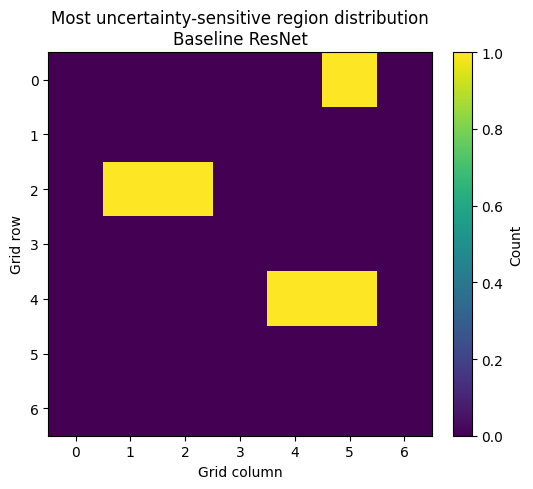

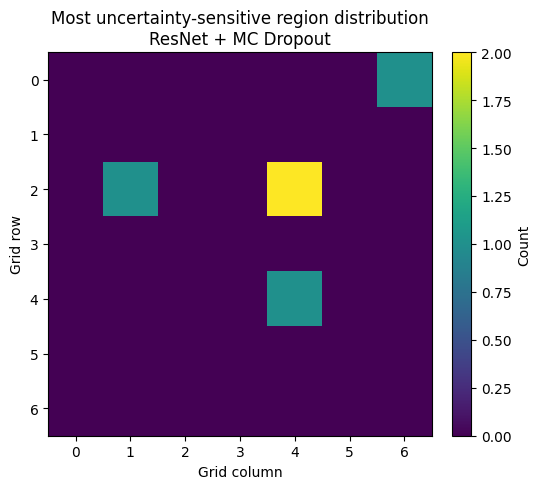

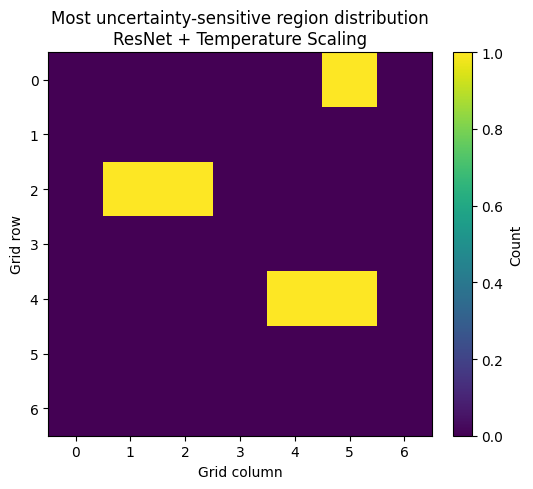

In [ ]:
# =========================
# 20. Distribution of uncertainty-sensitive regions over the 7×7 grid
# =========================

grid_distribution = (
    top_regions
    .groupby(["method", "method_display", "grid_row", "grid_col"])
    .size()
    .reset_index(name="count")
)

grid_distribution.to_csv(OUTPUT_DIR / "uncertainty_sensitive_region_grid_distribution.csv", index=False)

def plot_grid_distribution(method, save=True):
    one = grid_distribution[grid_distribution["method"] == method].copy()
    grid = np.zeros((GRID_SIZE, GRID_SIZE))

    for _, row in one.iterrows():
        grid[int(row["grid_row"]), int(row["grid_col"])] = row["count"]

    plt.figure(figsize=(6, 5))
    im = plt.imshow(grid)
    plt.title(f"Most uncertainty-sensitive region distribution\n{METHOD_DISPLAY[method]}")
    plt.xlabel("Grid column")
    plt.ylabel("Grid row")
    plt.colorbar(im, fraction=0.046, pad=0.04, label="Count")
    plt.tight_layout()

    if save:
        plt.savefig(OUTPUT_DIR / f"grid_distribution_{method}.png", dpi=300, bbox_inches="tight")

    plt.show()


for method in methods_to_run:
    plot_grid_distribution(method)


In [ ]:
# =========================
# 21. Simple ScoreCAM implementation
# =========================

class SimpleScoreCAM:
    def __init__(self, model, target_layer, device):
        self.model = model
        self.target_layer = target_layer
        self.device = device
        self.activations = None
        self.hook = self.target_layer.register_forward_hook(self._save_activation)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def generate(self, input_tensor, target_class=None, max_channels=64):
        """
        Lightweight ScoreCAM.
        It uses only the first max_channels feature maps for speed.
        """
        self.model.eval()
        input_tensor = input_tensor.to(self.device)

        with torch.no_grad():
            logits = self.model(input_tensor)
            probs = F.softmax(logits, dim=1)
            if target_class is None:
                target_class = int(torch.argmax(probs, dim=1).item())

        activations = self.activations.clone()  # [1, C, H, W]
        _, C, H, W = activations.shape
        C_use = min(C, max_channels)
        activations = activations[:, :C_use, :, :]

        scorecam = torch.zeros((1, 1, H, W), device=self.device)

        for ch in range(C_use):
            fmap = F.relu(activations[:, ch:ch+1, :, :])

            if torch.isclose(fmap.max(), fmap.min()):
                continue

            fmap_norm = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
            fmap_up = F.interpolate(
                fmap_norm,
                size=input_tensor.shape[2:],
                mode="bilinear",
                align_corners=False
            )

            masked_input = input_tensor * fmap_up

            with torch.no_grad():
                masked_logits = self.model(masked_input)
                masked_probs = F.softmax(masked_logits, dim=1)
                weight = masked_probs[0, target_class]

            scorecam += weight * fmap

        scorecam = F.relu(scorecam)
        scorecam = F.interpolate(
            scorecam,
            size=input_tensor.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        cam = scorecam.squeeze().detach().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam

    def remove_hooks(self):
        self.hook.remove()


scorecam_baseline = SimpleScoreCAM(baseline_model, baseline_model.layer4[-1], DEVICE)
scorecam_mc = SimpleScoreCAM(mc_model, mc_model.layer4[-1], DEVICE)


def get_scorecam_for_method(method, input_tensor, target_class):
    # Temperature scaling only rescales logits, so its spatial ScoreCAM is the same as baseline.
    if method == METHOD_MC:
        return scorecam_mc.generate(
            input_tensor,
            target_class=target_class,
            max_channels=SCORECAM_MAX_CHANNELS
        )
    else:
        return scorecam_baseline.generate(
            input_tensor,
            target_class=target_class,
            max_channels=SCORECAM_MAX_CHANNELS
        )


In [ ]:
# =========================
# ScoreCAM overlap setting
# =========================

# False = skip ScoreCAM overlap for now
# True = run ScoreCAM overlap analysis, but it can be slow
RUN_SCORECAM_OVERLAP = False

print("RUN_SCORECAM_OVERLAP:", RUN_SCORECAM_OVERLAP)

RUN_SCORECAM_OVERLAP: False


In [ ]:
# =========================
# 22. ScoreCAM region vs uncertainty-sensitive region overlap
# =========================

def compute_scorecam_region_overlap(row, top_percent=20):
    """
    Compare the most uncertainty-sensitive 7×7 grid cell with the top ScoreCAM activation region.

    Output meaning:
    - mean_scorecam_in_region: average ScoreCAM activation inside the selected grid cell.
    - max_scorecam_in_region: maximum ScoreCAM activation inside the selected grid cell.
    - top_scorecam_overlap_ratio: within that grid cell, proportion of pixels that belong to ScoreCAM top-percent pixels.
    """
    method = row["method"]
    filepath = row["filepath"]
    target_class = int(row["original_pred_label"])

    _, input_tensor = load_image_tensor(filepath)
    cam = get_scorecam_for_method(method, input_tensor, target_class=target_class)

    H, W = cam.shape
    grid_size = GRID_SIZE

    r = int(row["grid_row"])
    c = int(row["grid_col"])

    cell_h = H / grid_size
    cell_w = W / grid_size

    y1 = int(r * cell_h)
    y2 = int((r + 1) * cell_h) if r < grid_size - 1 else H
    x1 = int(c * cell_w)
    x2 = int((c + 1) * cell_w) if c < grid_size - 1 else W

    region_cam = cam[y1:y2, x1:x2]

    threshold = np.percentile(cam, 100 - top_percent)
    top_cam_mask = cam >= threshold
    region_top_cam_mask = top_cam_mask[y1:y2, x1:x2]

    return {
        "method": method,
        "method_display": METHOD_DISPLAY[method],
        "sample_id": int(row["sample_id"]),
        "filepath": filepath,
        "true_class": row["true_class"],
        "baseline_case_type": row["baseline_case_type"],
        "original_pred_class": row["original_pred_class"],
        "masked_pred_class": row["masked_pred_class"],
        "prediction_changed": bool(row["prediction_changed"]),
        "grid_row": r,
        "grid_col": c,
        "entropy_change": float(row["entropy_change"]),
        "abs_entropy_change": float(abs(row["entropy_change"])),
        "confidence_change": float(row["confidence_change"]),
        "mean_scorecam_in_region": float(region_cam.mean()),
        "max_scorecam_in_region": float(region_cam.max()),
        "top_scorecam_overlap_ratio": float(region_top_cam_mask.mean())
    }


if RUN_SCORECAM_OVERLAP:
    overlap_records = []

    for _, row in tqdm(top_regions.iterrows(), total=len(top_regions)):
        overlap_records.append(
            compute_scorecam_region_overlap(row, top_percent=SCORECAM_TOP_PERCENT)
        )

    overlap_df = pd.DataFrame(overlap_records)
    overlap_df.to_csv(OUTPUT_DIR / "scorecam_overlap_with_uncertainty_regions_by_method.csv", index=False)

    overlap_summary = overlap_df.groupby(["method", "method_display"]).agg(
        n_samples=("sample_id", "nunique"),
        mean_overlap_ratio=("top_scorecam_overlap_ratio", "mean"),
        median_overlap_ratio=("top_scorecam_overlap_ratio", "median"),
        mean_scorecam_activation_in_region=("mean_scorecam_in_region", "mean"),
        median_scorecam_activation_in_region=("mean_scorecam_in_region", "median"),
        mean_abs_entropy_change=("abs_entropy_change", "mean"),
        prediction_changed_rate=("prediction_changed", "mean")
    ).reset_index()

    overlap_summary.to_csv(OUTPUT_DIR / "scorecam_overlap_summary_by_method.csv", index=False)
    display(overlap_summary.round(4))
else:
    print("RUN_SCORECAM_OVERLAP is False. Skipping ScoreCAM overlap analysis.")


RUN_SCORECAM_OVERLAP is False. Skipping ScoreCAM overlap analysis.


In [ ]:
# =========================
# 23. Visualisation helpers for report figures
# =========================

import matplotlib.patches as patches


def plot_regional_entropy_map(sample_id, method, save=True):
    one = regional_df[
        (regional_df["sample_id"] == sample_id) &
        (regional_df["method"] == method)
    ].copy()

    if len(one) == 0:
        raise ValueError("No regional result found for this sample_id and method.")

    filepath = one["filepath"].iloc[0]
    original_img = Image.open(filepath).convert("L")

    entropy_map = np.zeros((GRID_SIZE, GRID_SIZE))
    for _, row in one.iterrows():
        entropy_map[int(row["grid_row"]), int(row["grid_col"])] = row["entropy_change"]

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original_img, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    im = plt.imshow(entropy_map)
    plt.title(f"Regional Entropy Change\n{METHOD_DISPLAY[method]}")
    plt.xlabel("Grid column")
    plt.ylabel("Grid row")
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.tight_layout()

    if save:
        plt.savefig(
            OUTPUT_DIR / f"sample_{sample_id}_{method}_regional_entropy_map.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


def plot_scorecam_uncertainty_overlay(sample_id, method, save=True):
    if not RUN_SCORECAM_OVERLAP:
        raise ValueError("ScoreCAM overlap was not computed. Set RUN_SCORECAM_OVERLAP=True first.")

    one_region = top_regions[
        (top_regions["sample_id"] == sample_id) &
        (top_regions["method"] == method)
    ].copy()

    if len(one_region) == 0:
        raise ValueError("No top region found for this sample_id and method.")

    row = one_region.iloc[0]
    filepath = row["filepath"]
    original_img = Image.open(filepath).convert("L")
    img_w, img_h = original_img.size

    _, input_tensor = load_image_tensor(filepath)
    cam = get_scorecam_for_method(
        method,
        input_tensor,
        target_class=int(row["original_pred_label"])
    )

    cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize(original_img.size)
    cam_resized = np.array(cam_img).astype(np.float32) / 255.0

    # Entropy map resized to image size
    one_all = regional_df[
        (regional_df["sample_id"] == sample_id) &
        (regional_df["method"] == method)
    ].copy()

    entropy_map = np.zeros((GRID_SIZE, GRID_SIZE))
    for _, rrow in one_all.iterrows():
        entropy_map[int(rrow["grid_row"]), int(rrow["grid_col"])] = rrow["entropy_change"]

    max_abs = np.max(np.abs(entropy_map)) + 1e-8
    entropy_img = Image.fromarray(entropy_map.astype(np.float32)).resize(
        original_img.size,
        resample=Image.NEAREST
    )
    entropy_resized = np.array(entropy_img).astype(np.float32)

    top_r = int(row["grid_row"])
    top_c = int(row["grid_col"])
    cell_w = img_w / GRID_SIZE
    cell_h = img_h / GRID_SIZE

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

    axes[0].imshow(original_img, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(original_img, cmap="gray")
    axes[1].imshow(cam_resized, alpha=0.45)
    axes[1].set_title("ScoreCAM")
    axes[1].axis("off")

    axes[2].imshow(original_img, cmap="gray")
    im = axes[2].imshow(entropy_resized, alpha=0.35, vmin=-max_abs, vmax=max_abs)
    axes[2].set_title("Signed Entropy Change")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    axes[3].imshow(original_img, cmap="gray")
    axes[3].imshow(cam_resized, alpha=0.40)
    axes[3].imshow(entropy_resized, alpha=0.30, vmin=-max_abs, vmax=max_abs)

    rect = patches.Rectangle(
        (top_c * cell_w, top_r * cell_h),
        cell_w,
        cell_h,
        linewidth=3,
        edgecolor="red",
        facecolor="none"
    )
    axes[3].add_patch(rect)
    axes[3].set_title("ScoreCAM + UQ-sensitive Region")
    axes[3].axis("off")

    plt.suptitle(
        f"Sample {sample_id} | {METHOD_DISPLAY[method]} | "
        f"True: {row['true_class']} | Pred: {row['original_pred_class']} | "
        f"ΔEntropy={row['entropy_change']:.3f}",
        fontsize=11
    )
    plt.tight_layout()

    if save:
        plt.savefig(
            OUTPUT_DIR / f"sample_{sample_id}_{method}_scorecam_uq_overlay.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


# Example usage after full run:
# plot_regional_entropy_map(sample_id=1, method=METHOD_BASELINE)
# plot_scorecam_uncertainty_overlay(sample_id=1, method=METHOD_BASELINE)


In [ ]:
# =========================
# 24. Final report tables
# =========================

# 1) Overall model/uncertainty metrics
print("===== Overall uncertainty/calibration metrics =====")
display(metrics_summary.round(4))

# 2) Regional occlusion summary
print("===== Regional occlusion summary =====")
display(regional_summary.round(4))

# 3) ScoreCAM overlap summary
if RUN_SCORECAM_OVERLAP:
    print("===== ScoreCAM-UQ overlap summary =====")
    display(overlap_summary.round(4))

# 4) Main table for report
report_summary = metrics_summary.merge(
    regional_df.groupby(["method", "method_display"]).agg(
        occlusion_prediction_changed_rate=("prediction_changed", "mean"),
        occlusion_mean_entropy_change=("entropy_change", "mean"),
        occlusion_mean_abs_entropy_change=("abs_entropy_change", "mean")
    ).reset_index(),
    on=["method", "method_display"],
    how="left"
)

if RUN_SCORECAM_OVERLAP:
    report_summary = report_summary.merge(
        overlap_summary[["method", "method_display", "mean_overlap_ratio", "median_overlap_ratio"]],
        on=["method", "method_display"],
        how="left"
    )

report_summary.to_csv(OUTPUT_DIR / "final_report_summary_table.csv", index=False)
report_summary.round(4)


===== Overall uncertainty/calibration metrics =====


,method,method_display,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,mean_confidence,mean_entropy,brier_score,nll,ece
0,baseline_resnet,Baseline ResNet,0.9424,0.9505,0.9494,0.9495,0.9919,0.9506,0.1375,0.0853,0.1585,0.0098
1,resnet_mc_dropout,ResNet + MC Dropout,0.9458,0.9551,0.9559,0.9555,0.9927,0.9579,0.1117,0.0842,0.1551,0.0150
2,resnet_temperature_scaling,ResNet + Temperature Scaling,0.9424,0.9505,0.9494,0.9495,0.9919,0.9492,0.1417,0.0853,0.1581,0.0088


===== Regional occlusion summary =====


,method,method_display,baseline_case_type,n_samples,n_regions,prediction_changed_rate,mean_confidence_change,mean_abs_confidence_change,mean_entropy_change,mean_abs_entropy_change
0,baseline_resnet,Baseline ResNet,Correct but uncertain,2,98,0.0918,-0.0119,0.0767,-0.0009,0.0964
1,baseline_resnet,Baseline ResNet,Incorrect but uncertain,3,147,0.2517,0.0080,0.0669,0.0009,0.0739
2,resnet_mc_dropout,ResNet + MC Dropout,Correct but uncertain,2,98,0.0408,-0.0252,0.0390,0.0420,0.0788
3,resnet_mc_dropout,ResNet + MC Dropout,Incorrect but uncertain,3,147,0.0680,-0.0124,0.0423,0.0125,0.0403
4,resnet_temperature_scaling,ResNet + Temperature Scaling,Correct but uncertain,2,98,0.0918,-0.0115,0.0758,-0.0008,0.0946
5,resnet_temperature_scaling,ResNet + Temperature Scaling,Incorrect but uncertain,3,147,0.2517,0.0079,0.0659,0.0012,0.0729


,method,method_display,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,mean_confidence,mean_entropy,brier_score,nll,ece,occlusion_prediction_changed_rate,occlusion_mean_entropy_change,occlusion_mean_abs_entropy_change
0,baseline_resnet,Baseline ResNet,0.9424,0.9505,0.9494,0.9495,0.9919,0.9506,0.1375,0.0853,0.1585,0.0098,0.1878,0.0002,0.0829
1,resnet_mc_dropout,ResNet + MC Dropout,0.9458,0.9551,0.9559,0.9555,0.9927,0.9579,0.1117,0.0842,0.1551,0.0150,0.0571,0.0243,0.0557
2,resnet_temperature_scaling,ResNet + Temperature Scaling,0.9424,0.9505,0.9494,0.9495,0.9919,0.9492,0.1417,0.0853,0.1581,0.0088,0.1878,0.0004,0.0816


In [50]:
print("OUTPUT_DIR =", OUTPUT_DIR)

import os

for file in os.listdir(OUTPUT_DIR):
    if file.endswith(".csv"):
        print(file)

OUTPUT_DIR = uq_resnet_occlusion_outputs
regional_occlusion_summary_by_method_case.csv
calibration_bins_baseline_resnet.csv
all_entropy_decrease_regions.csv
calibration_bins_resnet_temperature_scaling.csv
regional_occlusion_resnet_temperature_scaling.csv
most_uncertainty_sensitive_region_by_method.csv
final_report_summary_table.csv
baseline_uncertain_samples_used_for_occlusion.csv
calibration_bins_resnet_mc_dropout.csv
regional_occlusion_resnet_mc_dropout.csv
uncertainty_sensitive_region_grid_distribution.csv
all_test_predictions_by_method.csv
regional_occlusion_baseline_resnet.csv
strongest_entropy_decrease_region_by_method_sample.csv
regional_occlusion_all_methods.csv
method_metrics_summary.csv
